<a href="https://colab.research.google.com/github/Vaibhavi7179/Vaibhavi7179/blob/main/cyber_security_thread_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Install libraries

In [2]:
!pip install pandas numpy scikit-learn matplotlib seaborn joblib

2.Upload libraties

In [3]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

import matplotlib.pyplot as plt
import seaborn as sns
import joblib

3.Load Dataset

In [4]:
data = pd.read_csv("cicids2017_cleaned.csv")

# Remove extra spaces in column names
data.columns = data.columns.str.strip()

print("Dataset Shape:", data.shape)
data.head()

Dataset Shape: (248007, 53)


,Destination Port,Flow Duration,Total Fwd Packets,Total Length of Fwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,...,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Max,Active Min,Idle Mean,Idle Max,Idle Min,Attack Type
0,22,1266342,41,2664,456,0,64.975610,109.864573,976,0,...,243.0,24.0,32.0,0.0,0.0,0.0,0.0,0.0,0.0,Normal Traffic
1,22,1319353,41,2664,456,0,64.975610,109.864573,976,0,...,243.0,24.0,32.0,0.0,0.0,0.0,0.0,0.0,0.0,Normal Traffic
2,22,160,1,0,0,0,0.000000,0.000000,0,0,...,243.0,0.0,32.0,0.0,0.0,0.0,0.0,0.0,0.0,Normal Traffic
3,22,1303488,41,2728,456,0,66.536585,110.129945,976,0,...,243.0,24.0,32.0,0.0,0.0,0.0,0.0,0.0,0.0,Normal Traffic
4,35396,77,1,0,0,0,0.000000,0.000000,0,0,...,290.0,0.0,32.0,0.0,0.0,0.0,0.0,0.0,0.0,Normal Traffic


4. Dataset info checkings

In [5]:
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 248007 entries, 0 to 248006
Data columns (total 53 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Destination Port             248007 non-null  int64  
 1   Flow Duration                248007 non-null  int64  
 2   Total Fwd Packets            248007 non-null  int64  
 3   Total Length of Fwd Packets  248007 non-null  int64  
 4   Fwd Packet Length Max        248007 non-null  int64  
 5   Fwd Packet Length Min        248007 non-null  int64  
 6   Fwd Packet Length Mean       248007 non-null  float64
 7   Fwd Packet Length Std        248007 non-null  float64
 8   Bwd Packet Length Max        248007 non-null  int64  
 9   Bwd Packet Length Min        248007 non-null  int64  
 10  Bwd Packet Length Mean       248007 non-null  float64
 11  Bwd Packet Length Std        248007 non-null  float64
 12  Flow Bytes/s                 248007 non-null  float64
 13 

,Destination Port,Flow Duration,Total Fwd Packets,Total Length of Fwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,...,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Max,Active Min,Idle Mean,Idle Max,Idle Min
count,248007.000000,2.480070e+05,248007.000000,2.480070e+05,248007.000000,248007.000000,248007.000000,248007.000000,248007.000000,248007.000000,...,248006.000000,248006.000000,248006.000000,248006.000000,2.480060e+05,2.480060e+05,2.480060e+05,2.480060e+05,2.480060e+05,2.480060e+05
mean,7855.124884,8.205099e+06,9.020282,3.700985e+02,116.922946,14.974323,34.416713,34.982787,262.844021,37.914740,...,9411.400236,1660.287025,6.628142,27.791457,5.156724e+04,1.159310e+05,3.357668e+04,2.568179e+06,2.634328e+06,2.468693e+06
std,16201.316363,2.655861e+07,870.387309,5.721087e+03,399.105234,33.580125,92.919542,136.859715,684.479833,65.601175,...,14013.451616,7915.398781,832.823223,7.667931,5.606251e+05,8.812921e+05,5.095419e+05,1.109580e+07,1.132682e+07,1.096391e+07
min,0.000000,-1.300000e+01,1.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-1.000000,-1.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,53.000000,5.200000e+01,1.000000,2.000000e+00,2.000000,0.000000,2.000000,0.000000,6.000000,0.000000,...,-1.000000,-1.000000,0.000000,20.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,443.000000,1.840000e+02,1.000000,1.200000e+01,6.000000,2.000000,6.000000,0.000000,6.000000,6.000000,...,1024.000000,0.000000,0.000000,24.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,5810.000000,6.246800e+04,2.000000,8.400000e+01,46.000000,33.000000,43.000000,0.000000,120.000000,63.000000,...,29200.000000,0.000000,1.000000,32.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,65529.000000,1.199999e+08,200755.000000,1.197199e+06,23360.000000,1472.000000,4183.057143,5463.493850,10220.000000,1460.000000,...,65535.000000,65535.000000,192491.000000,60.000000,1.100000e+08,1.100000e+08,1.100000e+08,1.200000e+08,1.200000e+08,1.200000e+08


5. Check  missing values

In [6]:
print(data.isnull().sum())

Destination Port               0
Flow Duration                  0
Total Fwd Packets              0
Total Length of Fwd Packets    0
Fwd Packet Length Max          0
Fwd Packet Length Min          0
Fwd Packet Length Mean         0
Fwd Packet Length Std          0
Bwd Packet Length Max          0
Bwd Packet Length Min          0
Bwd Packet Length Mean         0
Bwd Packet Length Std          0
Flow Bytes/s                   0
Flow Packets/s                 0
Flow IAT Mean                  0
Flow IAT Std                   0
Flow IAT Max                   0
Flow IAT Min                   0
Fwd IAT Total                  0
Fwd IAT Mean                   0
Fwd IAT Std                    0
Fwd IAT Max                    0
Fwd IAT Min                    0
Bwd IAT Total                  0
Bwd IAT Mean                   1
Bwd IAT Std                    1
Bwd IAT Max                    1
Bwd IAT Min                    1
Fwd Header Length              1
Bwd Header Length              1
Fwd Packet

6. Handle missing values

In [7]:
data.replace([np.inf, -np.inf], np.nan, inplace=True)
data.fillna(0, inplace=True)

In [8]:
data.columns

Index(['Destination Port', 'Flow Duration', 'Total Fwd Packets',
       'Total Length of Fwd Packets', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd Header Length', 'Bwd Header Length',
       'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length',
       'Max Packet Length', 'Packet Length Mean', 'Packet Length Std',
       'Packet Length Variance', 'FIN Flag Count', 'PSH Flag Count',
       'ACK Flag Count', 'Average Packet Size', 'Subflow Fwd Bytes',
       'Init_Win_bytes_forward', 'Init_Win_bytes_backward', 'act_data_p

7.checking columns

In [9]:
print(data.columns.tolist())

['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Length of Fwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'Average Packet Size', 'Subflow Fwd Bytes', 'Init_Win_bytes_forward', 'Init_Win_bytes_backward', 'act_data_pkt_fwd', 'min_seg_size_forward', 'Active Mean', 'Active Max', 'Active Min', 'Idle Mean', 'Idle Max', 'Id

In [10]:
data.columns = data.columns.str.strip()
print(data.columns.tolist())

['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Length of Fwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'Average Packet Size', 'Subflow Fwd Bytes', 'Init_Win_bytes_forward', 'Init_Win_bytes_backward', 'act_data_pkt_fwd', 'min_seg_size_forward', 'Active Mean', 'Active Max', 'Active Min', 'Idle Mean', 'Idle Max', 'Id

In [11]:
for col in data.columns:
    print(col)

Destination Port
Flow Duration
Total Fwd Packets
Total Length of Fwd Packets
Fwd Packet Length Max
Fwd Packet Length Min
Fwd Packet Length Mean
Fwd Packet Length Std
Bwd Packet Length Max
Bwd Packet Length Min
Bwd Packet Length Mean
Bwd Packet Length Std
Flow Bytes/s
Flow Packets/s
Flow IAT Mean
Flow IAT Std
Flow IAT Max
Flow IAT Min
Fwd IAT Total
Fwd IAT Mean
Fwd IAT Std
Fwd IAT Max
Fwd IAT Min
Bwd IAT Total
Bwd IAT Mean
Bwd IAT Std
Bwd IAT Max
Bwd IAT Min
Fwd Header Length
Bwd Header Length
Fwd Packets/s
Bwd Packets/s
Min Packet Length
Max Packet Length
Packet Length Mean
Packet Length Std
Packet Length Variance
FIN Flag Count
PSH Flag Count
ACK Flag Count
Average Packet Size
Subflow Fwd Bytes
Init_Win_bytes_forward
Init_Win_bytes_backward
act_data_pkt_fwd
min_seg_size_forward
Active Mean
Active Max
Active Min
Idle Mean
Idle Max
Idle Min
Attack Type


8.Label conversion

In [12]:
# ✅ UNIVERSAL FIX FOR LABEL ERROR

# Step 1: Clean column names (remove spaces)
data.columns = data.columns.str.strip()

# Step 2: Automatically detect label column
label_col = None
for col in data.columns:
    if 'label' in col.lower() or 'attack' in col.lower() or 'class' in col.lower():
        label_col = col
        break

# Step 3: Check if found
if label_col is None:
    raise Exception("❌ Label column not found. Run: print(data.columns)")

# Step 4: Convert to binary safely
data[label_col] = data[label_col].astype(str).str.strip().str.upper()
data[label_col] = data[label_col].apply(lambda x: 0 if x == 'BENIGN' else 1)

# Step 5: Rename to standard name
data.rename(columns={label_col: 'Label'}, inplace=True)

# Step 6: Verify
print("✅ Label column fixed successfully!")
print(data['Label'].value_counts())

✅ Label column fixed successfully!
Label
1    248007
Name: count, dtype: int64


9.Feature selection

In [13]:
# Clean column names
data.columns = data.columns.str.strip()

# Use all numeric columns except Label (SAFE METHOD)
X = data.select_dtypes(include=['number'])

# Remove Label from features
if 'Label' in X.columns:
    X = X.drop('Label', axis=1)

y = data['Label']

print("✅ Features Shape:", X.shape)
print("✅ Target Shape:", y.shape)

✅ Features Shape: (248007, 52)
✅ Target Shape: (248007,)


10. Feature scaling

In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

11. Train test split

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print("Training Size:", X_train.shape)
print("Testing Size:", X_test.shape)

Training Size: (198405, 52)
Testing Size: (49602, 52)


12.Model training

In [16]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)

model.fit(X_train, y_train)

print("✅ Model Training Completed")

✅ Model Training Completed


13.Prediction

In [17]:
y_pred = model.predict(X_test)

14.Evaluation metrics

In [18]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           1       1.00      1.00      1.00     49602

    accuracy                           1.00     49602
   macro avg       1.00      1.00      1.00     49602
weighted avg       1.00      1.00      1.00     49602



15.Confusion matrix

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


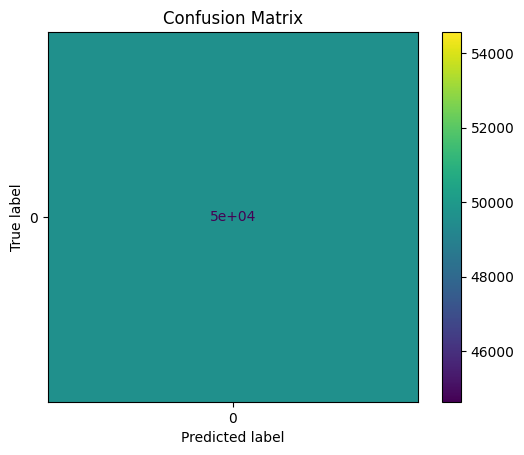

In [19]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

16.Visualization

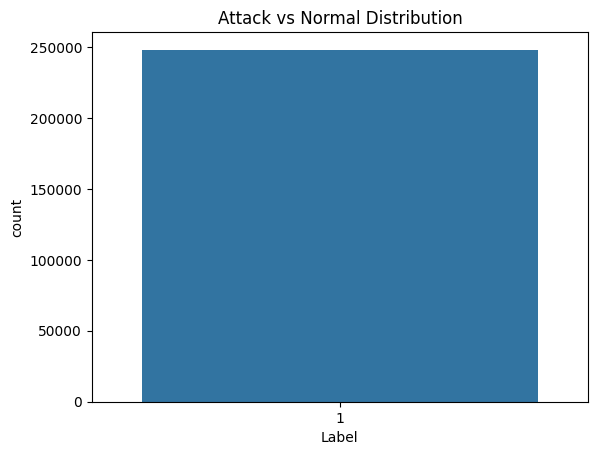

In [20]:
sns.countplot(x=y)
plt.title("Attack vs Normal Distribution")
plt.show()

17.Feature importance

In [28]:
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

print(feature_importance)

                        Feature  Importance
0              Destination Port         0.0
1                 Flow Duration         0.0
2             Total Fwd Packets         0.0
3   Total Length of Fwd Packets         0.0
4         Fwd Packet Length Max         0.0
5         Fwd Packet Length Min         0.0
6        Fwd Packet Length Mean         0.0
7         Fwd Packet Length Std         0.0
8         Bwd Packet Length Max         0.0
9         Bwd Packet Length Min         0.0
10       Bwd Packet Length Mean         0.0
11        Bwd Packet Length Std         0.0
12                 Flow Bytes/s         0.0
13               Flow Packets/s         0.0
14                Flow IAT Mean         0.0
15                 Flow IAT Std         0.0
16                 Flow IAT Max         0.0
17                 Flow IAT Min         0.0
18                Fwd IAT Total         0.0
19                 Fwd IAT Mean         0.0
20                  Fwd IAT Std         0.0
21                  Fwd IAT Max 

18.Save model

In [23]:
joblib.dump(model, "cybersecurity_model.pkl")
print("Model Saved Successfully!")

Model Saved Successfully!


19.Test custom input

In [24]:
# Take one sample from test data
sample = X_test[0].reshape(1, -1)

prediction = model.predict(sample)

print("Prediction:", "Attack" if prediction[0] == 1 else "Normal")

Prediction: Attack


20.Download model

In [25]:
from google.colab import files
files.download("cybersecurity_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Sample dataset

In [26]:
# Create small sample (1000 rows)
sample_data = data.sample(n=1000, random_state=42)

sample_data.to_csv("sample_cicids.csv", index=False)

print("✅ Sample dataset created!")

✅ Sample dataset created!
